# Sport-climbing grade density — Red River Gorge

**How many sport routes of each YDS grade live in each crag and wall?**

Answerable for any grade band (e.g. "how many 5.10s in this crag?") and any unit of the area
hierarchy. The target is the Red River Gorge, KY, but the area is a **parameter** — change the
parameter cell to retarget anywhere in the USA export without touching code.

Logic lives in [`climbing_density.py`](climbing_density.py) (unit-tested); this notebook handles
parameters, the filtering pipeline, aggregation, and visualization. Data comes from a local
parquet produced by the one-time OpenBeta export — see [`DATA.md`](DATA.md).

## Parameters

Change these to retarget. `AREA` is matched by **membership** in `path_tokens`, so it is robust to how deeply the area nests.

In [1]:
import collections

import matplotlib.pyplot as plt
import pandas as pd

import climbing_density as cd

# --- Parameters -------------------------------------------------------------------------
PARQUET_PATH = "data/usa-sport-climbs.parquet"
STATE = "Kentucky"          # coarse pre-filter on state_province; set to None to skip
AREA = "Red River Gorge"    # matched by MEMBERSHIP in path_tokens (depth-robust)
CRAG_OFFSET = 2             # crag = path_tokens[index(AREA) + CRAG_OFFSET]
                            # Resolved from the data (spec §10): for RRG, AREA+1 is the preserve/region
                            # grouping (PMRP, Muir Valley, ...) while AREA+2 is the crag (The Motherlode,
                            # Drive-By Crag, ...). Set to 1 for a coarser preserve-level view.
# ----------------------------------------------------------------------------------------

pd.set_option("display.max_rows", 250)
pd.set_option("display.max_columns", 80)

## 1 · Load → focus on the area → surface unparsed grades → derive hierarchy

In [2]:
raw = cd.load_climbs(PARQUET_PATH)
print(f"Loaded {len(raw):,} USA sport routes from the export.")

# Focus on the target area (coarse state filter, then AREA membership in path_tokens).
area_df = cd.filter_area(raw, state=STATE, area=AREA)
print(f"{len(area_df):,} routes within {AREA!r} (state={STATE!r}).")

# Surface the unparsed / non-YDS grade bucket BEFORE dropping anything (never silent).
unparsed = cd.unparsed_grades(area_df)
print(f"\nUnparsed / non-YDS grade values in this area: {len(unparsed)}")
if len(unparsed):
    display(unparsed["grade_yds"].value_counts().head(10).rename("routes").to_frame())

# Keep sport + parseable (deduped), add grade columns, derive the crag/wall hierarchy.
df = cd.filter_sport(area_df)
df = cd.add_grade_columns(df)
df = cd.derive_hierarchy(df, area=AREA, crag_offset=CRAG_OFFSET)

n_fallback = int(df["crag_is_fallback"].sum())
print(f"\nAnalysis set: {len(df):,} sport routes with a parseable YDS grade.")
print(f"Routes where the crag has no deeper named wall, so wall == crag: "
      f"{n_fallback} ({n_fallback / max(len(df), 1):.0%}) — expected; many crags aren't sub-divided.")
df.head()

Loaded 63,160 USA sport routes from the export.
1,859 routes within 'Red River Gorge' (state='Kentucky').

Unparsed / non-YDS grade values in this area: 3


,routes
grade_yds,
3rd,3



Analysis set: 1,856 sport routes with a parseable YDS grade.
Routes where the crag has no deeper named wall, so wall == crag: 1679 (90%) — expected; many crags aren't sub-divided.


,climb_id,climb_name,grade_yds,is_sport,is_trad,country,state_province,region,path_tokens,latitude,longitude,grade_letter,grade_band,grade_rank,parsed,wall,crag,wall_key,crag_key,crag_is_fallback
0,"b',\x16\x8dY\x03""V\xd6\xb7\x07\xa3o\xae\xf7\xc...",Unconditional,5.10a,True,None,USA,Kentucky,Red River Gorge,"[USA, Kentucky, Red River Gorge, Bald Rock For...",37.64235,-83.71178,5.10a,5.10,101,True,"Unlode, The","Unlode, The","(USA, Kentucky, Red River Gorge, Bald Rock For...","(USA, Kentucky, Red River Gorge, Bald Rock For...",True
1,"b'9\xeaZ\x1b\x92\x9bR\xa7\xbd7\x1b\x0c""\xef\x1...",Undesirable,5.11c,True,None,USA,Kentucky,Red River Gorge,"[USA, Kentucky, Red River Gorge, Bald Rock For...",37.64235,-83.71178,5.11c,5.11,113,True,"Unlode, The","Unlode, The","(USA, Kentucky, Red River Gorge, Bald Rock For...","(USA, Kentucky, Red River Gorge, Bald Rock For...",True
2,"b""<\xccr\xbe\xcfcY\x87\x82\xbf3|\xc6r'\x12""",Unfulfilling,5.10a,True,None,USA,Kentucky,Red River Gorge,"[USA, Kentucky, Red River Gorge, Bald Rock For...",37.64235,-83.71178,5.10a,5.10,101,True,"Unlode, The","Unlode, The","(USA, Kentucky, Red River Gorge, Bald Rock For...","(USA, Kentucky, Red River Gorge, Bald Rock For...",True
3,b'auwP\xc7\xf2]q\x86@\xe23u\xdf\xb1`',Unworthy,5.11a,True,None,USA,Kentucky,Red River Gorge,"[USA, Kentucky, Red River Gorge, Bald Rock For...",37.64235,-83.71178,5.11a,5.11,111,True,"Unlode, The","Unlode, The","(USA, Kentucky, Red River Gorge, Bald Rock For...","(USA, Kentucky, Red River Gorge, Bald Rock For...",True
4,b'vd\x80\x87\xd6\x98S8\xbc\xba\x02\x80\x9c\xce...,"Undoubtedly, Still Better than Trad",5.10a,True,None,USA,Kentucky,Red River Gorge,"[USA, Kentucky, Red River Gorge, Bald Rock For...",37.64235,-83.71178,5.10a,5.10,101,True,"Unlode, The","Unlode, The","(USA, Kentucky, Red River Gorge, Bald Rock For...","(USA, Kentucky, Red River Gorge, Bald Rock For...",True


## 2 · Sanity-check the crag anchor (spec §10)

`crag = path_tokens[index(AREA) + CRAG_OFFSET]`. For RRG this is **resolved to `CRAG_OFFSET = 2`**:
`AREA+1` is the preserve/region grouping (PMRP, Muir Valley, …) and `AREA+2` is the crag
(The Motherlode, Drive-By Crag, …). The cell below prints the levels below `AREA`, so when you
retarget to another area you can re-judge the granularity and adjust `CRAG_OFFSET` — no code change.

In [3]:
def levels_below_area(frame, area):
    by_depth = collections.defaultdict(collections.Counter)
    for toks in frame["path_tokens"]:
        toks = list(toks)
        if area in toks:
            i = toks.index(area)
            for depth, tok in enumerate(toks[i + 1:], start=1):
                by_depth[depth][tok] += 1
    return by_depth

levels = levels_below_area(df, AREA)
for depth in sorted(levels):
    counter = levels[depth]
    print(f"AREA+{depth}: {len(counter)} distinct tokens across {sum(counter.values())} routes")
    for name, n in counter.most_common(8):
        print(f"      {name!r}: {n}")
    print()

print(f"Current CRAG_OFFSET = {CRAG_OFFSET}  ->  crag = the AREA+{CRAG_OFFSET} token.")

AREA+1: 8 distinct tokens across 1856 routes
      'Pendergrass-Murray Recreational Preserve (PMRP)': 439
      'Miller Fork Recreational Preserve (MFRP)': 388
      'Muir Valley': 336
      'Bald Rock Fork Recreational Preserve (BRRP)': 243
      'Cathedral Domain Climbing Area (CDCA)': 164
      'Natural Bridge Region': 152
      'Northern Gorge': 128
      'Southern Region Crags (Miscellaneous)': 6

AREA+2: 135 distinct tokens across 1856 routes
      'Chocolate Factory': 75
      'Motherlode, The': 63
      'Drive-By Crag': 48
      'The Zoo': 43
      'Infirmary, The': 38
      'Solar Collector/Gold Coast': 36
      'Hole in the Wall': 36
      'Graining Fork Nature Preserve (a.k.a. Roadside Crag)': 35

AREA+3: 18 distinct tokens across 177 routes
      '(5) Undertow Wall': 23
      'The Old Zoo': 21
      '(1) Buckeye Buttress': 13
      'Gypsy Camp': 13
      'Bird Cage Sector': 12
      '(2) Warm-Up Wall': 12
      'The New Zoo': 10
      'UnHoley Wall, The': 10

Current CRAG_O

## 3 · Crag × grade-band matrix (raw counts)

Columns are ordered by difficulty (`grade_rank`), not lexically. Sort by any grade, e.g. `crag_band.sort_values('5.12', ascending=False)`.

In [4]:
crag_band = cd.density_matrix(df, unit="crag", grade_level="band")
crag_band

,5.1,5.2,5.3,5.4,5.5,5.6,5.7,5.8,5.9,5.10,5.11,5.12,5.13,5.14,total_routes
crag,,,,,,,,,,,,,,,
Chocolate Factory,0,0,0,0,0,0,0,0,4,15,20,23,10,3,75
"Motherlode, The",0,0,0,0,0,0,0,0,0,1,15,29,15,3,63
Drive-By Crag,0,0,0,0,0,0,0,0,0,12,13,12,9,2,48
The Zoo,0,0,0,0,0,0,0,0,2,8,17,13,1,2,43
"Infirmary, The",0,0,0,0,0,0,1,4,1,6,11,14,1,0,38
Solar Collector/Gold Coast,0,0,0,0,1,0,0,2,2,4,14,8,4,1,36
Hole in the Wall,0,0,0,0,0,0,0,1,2,6,21,5,1,0,36
Graining Fork Nature Preserve (a.k.a. Roadside Crag),0,0,0,0,0,0,2,2,4,8,6,12,1,0,35
The Gallery,0,0,0,0,0,0,0,1,1,11,10,10,1,1,35


## 4 · Wall × grade-band matrix (raw counts)

Walls are the true leaf areas. Top 30 by total routes shown.

In [5]:
wall_band = cd.density_matrix(df, unit="wall", grade_level="band")
wall_band.head(30)

,5.1,5.2,5.3,5.4,5.5,5.6,5.7,5.8,5.9,5.10,5.11,5.12,5.13,5.14,total_routes
wall,,,,,,,,,,,,,,,
Chocolate Factory,0,0,0,0,0,0,0,0,4,15,20,23,10,3,75
Drive-By Crag,0,0,0,0,0,0,0,0,0,12,13,12,9,2,48
"Infirmary, The",0,0,0,0,0,0,1,4,1,6,11,14,1,0,38
Solar Collector/Gold Coast,0,0,0,0,1,0,0,2,2,4,14,8,4,1,36
Graining Fork Nature Preserve (a.k.a. Roadside Crag),0,0,0,0,0,0,2,2,4,8,6,12,1,0,35
The Gallery,0,0,0,0,0,0,0,1,1,11,10,10,1,1,35
"Bear's Den, The",0,0,0,0,0,0,0,1,1,7,13,8,3,0,33
Secret Garden,0,0,0,0,0,0,1,0,3,11,13,3,0,0,31
Chica Bonita Wall,0,0,0,0,1,0,1,1,3,9,11,4,0,0,30


## 5 · Top crags for a chosen grade

The headline question: which crags have the most routes at a given grade? Change `GRADE` (band like `5.10`, or a letter like `5.10a`).

In [6]:
GRADE = "5.10"
display(cd.top_units_for_grade(df, grade=GRADE, unit="crag", n=10))
display(cd.top_units_for_grade(df, grade=GRADE, unit="wall", n=10))

,crag,count
0,Chocolate Factory,15
1,Real Deep End,14
2,Drive-By Crag,12
3,The Gallery,11
4,Secret Garden,11
5,White Pine Trail,11
6,Bruise Brothers Wall,10
7,Volunteer Wall,9
8,Velo Crag,9
9,Chica Bonita Wall,9


,wall,count
0,Chocolate Factory,15
1,Real Deep End,14
2,Drive-By Crag,12
3,Secret Garden,11
4,The Gallery,11
5,Bruise Brothers Wall,10
6,Velo Crag,9
7,Volunteer Wall,9
8,Monastery,9
9,Camelot,9


## 6 · Grade histogram for one crag/wall

Defaults to the crag with the most routes; set `FOCUS_CRAG` to any name from the matrices above.

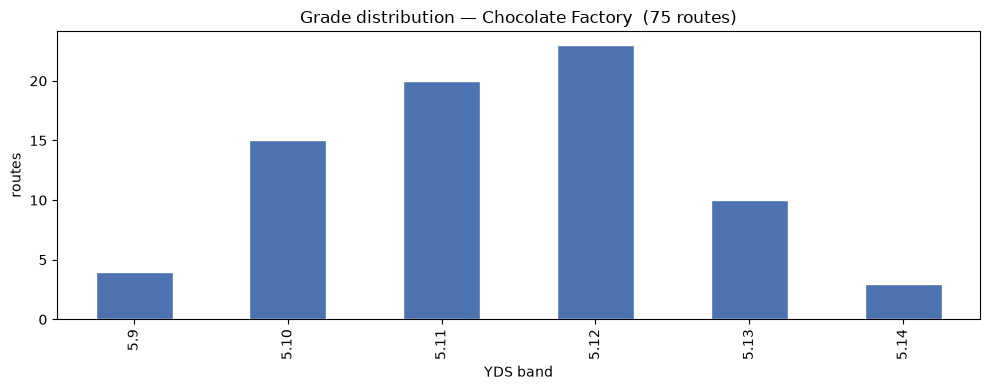

In [7]:
FOCUS_CRAG = crag_band.index[0]
sub = df[df["crag"] == FOCUS_CRAG]

counts = (sub.groupby("grade_band")["grade_rank"].agg(routes="size", rank="min")
             .sort_values("rank")["routes"])

ax = counts.plot.bar(figsize=(10, 4), color="#4C72B0", edgecolor="white")
ax.set_title(f"Grade distribution — {FOCUS_CRAG}  ({len(sub):,} routes)")
ax.set_xlabel("YDS band")
ax.set_ylabel("routes")
plt.tight_layout()
plt.show()

## 7 · Heatmap — grade distribution across the walls of one crag

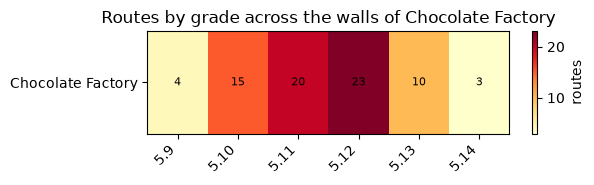

In [8]:
crag_walls = df[df["crag"] == FOCUS_CRAG]
mat = cd.density_matrix(crag_walls, unit="wall", grade_level="band").drop(columns="total_routes")

fig, ax = plt.subplots(figsize=(min(2 + 0.7 * mat.shape[1], 14),
                                min(1.5 + 0.45 * mat.shape[0], 16)))
im = ax.imshow(mat.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(mat.shape[1]), labels=mat.columns, rotation=45, ha="right")
ax.set_yticks(range(mat.shape[0]), labels=mat.index)
ax.set_title(f"Routes by grade across the walls of {FOCUS_CRAG}")
fig.colorbar(im, ax=ax, label="routes")
for r in range(mat.shape[0]):
    for c in range(mat.shape[1]):
        v = int(mat.values[r, c])
        if v:
            ax.text(c, r, v, ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()

---
**Retarget:** point `AREA`/`STATE` at any other US area (the export is country-scoped to the USA,
so no re-export is needed). If the area filter returns nothing, the error lists the closest names
present so you can fix the spelling.